Notebook for plotting and analyzing the results of output netcdf files from each model

In [1]:
import os
import sys
# import torch
# import logging
# import torch.nn as nn
# import torch.nn.functional as F
# from torch.utils.data import Dataset,DataLoader
# from torch.autograd import Variable
# import torchvision.models as models

# import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# from scipy.special import gamma, gammaln

# import copy
import datetime
import yaml

import importlib

# import tqdm

In [10]:
dirP_str = os.path.join(os.environ['HOME'], 
                    'Python',
                    'aerosol-scattering',
                    'library')
if dirP_str not in sys.path:
    sys.path.append(dirP_str)
    
import evid_nn

In [21]:
file_name_lst = [
    "/glade/derecho/scratch/mhayman/aerosol_poly_nn/output_analysis/full_aggregate_analysis_20260310T065310.nc"
]

In [22]:
for ds in nc_data_lst:
    ds.close()

In [23]:
nc_data_lst = []
x_rescale_lst = []
y_rescale_lst = []
for file in file_name_lst:
    nc_data_lst.append(xr.open_dataset(file))
    
    # get the rescaling data
    conf_reload, model_reload = evid_nn.load_poly_nn_model(nc_data_lst[-1].attrs['model'],name_str='hyper_best',device='cpu')
    x_scaler = evid_nn.rescale(0,1)
    x_scaler.set_config(**conf_reload['save_model']['x_scaler'])
    y_scaler = evid_nn.rescale(0,1)
    y_scaler.set_config(**conf_reload['save_model']['y_scaler'])

    x_rescale_lst.append(x_scaler)
    y_rescale_lst.append(y_scaler)

loading model from 
/glade/u/home/mhayman/Python/aerosol-scattering/models


In [24]:
act_data_ln_lst = []
centroid_data_ln_lst = []
centroid_ens_data_ln_lst = []

hr_lst = []
hr_ens_lst = []
hn_lst = []
hn_ens_lst = []

for m_idx, y_scaler in enumerate(y_rescale_lst):
    act_data_ln = y_scaler.unscale(np.stack([nc_data_lst[m_idx]['n_act'],nc_data_lst[m_idx]['r_act']],axis=1))
    centroid_data_ln = y_scaler.unscale(np.stack([nc_data_lst[m_idx]['n_centroid'],nc_data_lst[m_idx]['r_centroid']],axis=1))
    centroid_ens_data_ln = y_scaler.unscale(np.stack([nc_data_lst[m_idx]['n_ens_centroid'],nc_data_lst[m_idx]['r_ens_centroid']],axis=1))

    act_data_ln_lst.append(act_data_ln)
    centroid_data_ln_lst.append(centroid_data_ln)
    centroid_ens_data_ln_lst.append(centroid_ens_data_ln)

    # hr = np.histogram(np.abs(act_data_ln[:,1]-centroid_data_ln[:,1])*np.log10(np.exp(1)),bins=np.linspace(0,1,100))
    hr = np.histogram((act_data_ln[:,1]-centroid_data_ln[:,1])*np.log10(np.exp(1)),bins=np.linspace(-1,1,100))
    hr_ens = np.histogram((act_data_ln[:,1]-centroid_ens_data_ln[:,1])*np.log10(np.exp(1)),bins=np.linspace(-1,1,100))


    # hn = np.histogram(np.abs(act_data_ln[:,0]-centroid_data_ln[:,0])*np.log10(np.exp(1)),bins=np.linspace(0,2,100))
    hn = np.histogram((act_data_ln[:,0]-centroid_data_ln[:,0])*np.log10(np.exp(1)),bins=np.linspace(-2,2,100))
    hn_ens = np.histogram((act_data_ln[:,0]-centroid_ens_data_ln[:,0])*np.log10(np.exp(1)),bins=np.linspace(-2,2,100))

    hr_lst.append(hr)
    hr_ens_lst.append(hr_ens)
    hn_lst.append(hn)
    hn_ens_lst.append(hn_ens)

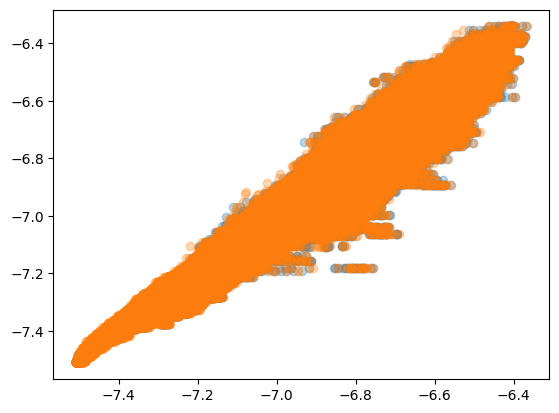

In [25]:
plt.figure()
plt.scatter(centroid_data_ln_lst[-1][:,1]*np.log10(np.exp(1)),act_data_ln_lst[-1][:,1]*np.log10(np.exp(1)),alpha=0.3)
plt.scatter(centroid_ens_data_ln_lst[-1][:,1]*np.log10(np.exp(1)),act_data_ln_lst[-1][:,1]*np.log10(np.exp(1)),alpha=0.3)

# plt.figure()
# plt.scatter(nc_data_lst[-1]['r_centroid'],nc_data_lst[-1]['r_act'])
# plt.scatter(nc_data_lst[-1]['r_ens_centroid'],nc_data_lst[-1]['r_act'])

In [26]:
# hist_out_label
hist_act_data_ln = y_rescale_lst[-1].unscale(hist_out_label)
hr_prior = np.histogram((act_data_ln[:,1]-np.mean(hist_act_data_ln[:,1]))*np.log10(np.exp(1)),bins=np.linspace(-1,1,100))

hn_prior = np.histogram((act_data_ln[:,0]-np.mean(hist_act_data_ln[:,0]))*np.log10(np.exp(1)),bins=np.linspace(-2,2,100))

NameError: name 'hist_out_label' is not defined

In [27]:
# total histogram of training/test/validation data
h_part_total = np.histogram2d(hist_out_label[:,1],hist_out_label[:,0],bins=np.linspace(0,1,500))


r_cdf_prior = np.cumsum(np.sum(h_part_total[0],axis=0))/np.sum(h_part_total[0])
n_cdf_prior = np.cumsum(np.sum(h_part_total[0],axis=1))/np.sum(h_part_total[0])

r_tot_interval = np.interp(percentile_lst,r_cdf_prior,0.5*(h_part_total[1][:-1]+h_part_total[1][1:]))
n_tot_interval = np.interp(percentile_lst,n_cdf_prior,0.5*(h_part_total[2][:-1]+h_part_total[2][1:]))

y_scaler = y_rescale_lst[-1]

percentile_prior_ln_lst = []
for i_per in range(r_interval_arr_lst[m_idx].shape[1]//2):
    print(f"{percentile_lst[i_per]} to {percentile_lst[-1-i_per]}")
    percentile_prior_ln_1 = y_scaler.unscale(np.array([[n_tot_interval[i_per]],[r_tot_interval[i_per]]]).T)
    percentile_prior_ln_2 = y_scaler.unscale(np.array([[n_tot_interval[-1-i_per]],[r_tot_interval[-1-i_per]]]).T)
    percentile_prior_ln_lst.append([percentile_prior_ln_1,percentile_prior_ln_2])

NameError: name 'h_part_total' is not defined

In [ ]:
percentile_data_ln_lst_lst = []
percentile_model_sets = []
for m_idx, y_scaler in enumerate(y_rescale_lst):
    percentile_data_ln_lst = []
    percentile_sets = []
    for i_per in range(r_interval_arr_lst[m_idx].shape[1]//2):
        print(f"{percentile_lst[i_per]} to {percentile_lst[-1-i_per]}")
        percentile_data_ln_1 = y_scaler.unscale(np.stack([n_interval_arr_lst[m_idx][:,i_per],r_interval_arr_lst[m_idx][:,i_per]],axis=1))
        percentile_data_ln_2 = y_scaler.unscale(np.stack([n_interval_arr_lst[m_idx][:,-1-i_per],r_interval_arr_lst[m_idx][:,-1-i_per]],axis=1))
        percentile_data_ln_lst.append([percentile_data_ln_1,percentile_data_ln_2])
        percentile_sets.append([percentile_lst[i_per],percentile_lst[-1-i_per]])

    percentile_data_ln_lst_lst.append(percentile_data_ln_lst)
    percentile_model_sets.append(percentile_sets)

In [ ]:
fig,ax = plt.subplots(1,2,figsize=(12,5))
plt_lst = [0,1,2]
for m_idx, hr in enumerate(hr_lst):
    if m_idx in plt_lst:
        label = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
        ax[0].plot(hr[1][:-1],hr[0]/np.sum(hr[0]),label=label)
    
    
        hn = hn_lst[m_idx]
        ax[1].plot(hn[1][:-1],hn[0]/np.sum(hn[0]),label=label)

ax[0].plot(hr_prior[1][:-1],hr_prior[0]/np.sum(hr_prior[0]),label="Prior",color='k',linestyle='--')

ax[0].set_xlabel('$Log_{10}$ Radius difference')
ax[0].grid(visible=True)
ax[0].set_ylabel("PDF")
ax[0].legend()

ax[1].plot(hn_prior[1][:-1],hn_prior[0]/np.sum(hn_prior[0]),label="Prior",color='k',linestyle='--')
ax[1].set_xlabel('$Log_{10}$ Number density difference')
ax[1].grid(visible=True)

fig,ax = plt.subplots(1,2,figsize=(12,5))
for m_idx, hr in enumerate(hr_lst):
    label = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    ax[0].plot(hr[1][:-1],np.cumsum(hr[0]/np.sum(hr[0])),label=label)
    

    hn = hn_lst[m_idx]
    ax[1].plot(hn[1][:-1],np.cumsum(hn[0]/np.sum(hn[0])),label=label)

ax[0].plot(hr_prior[1][:-1],np.cumsum(hr_prior[0]/np.sum(hr_prior[0])),label="Prior",color='k',linestyle='--')

ax[0].set_xlabel('$Log_{10}$ Radius difference')
ax[0].grid(visible=True)
ax[0].set_ylabel("CDF")
ax[0].legend()

ax[1].plot(hn_prior[1][:-1],np.cumsum(hn_prior[0]/np.sum(hn_prior[0])),label="Prior",color='k',linestyle='--')

ax[1].set_xlabel('$Log_{10}$ Number density difference')
ax[1].grid(visible=True)

In [ ]:
custom_label_lst = [r'2$\alpha$ 6$\beta$',r'2$\alpha$ 3$\beta$','355 nm']

In [ ]:
percentile_idx = 1
plt_lst = [0,1,2]
n_col = 4
# n_row = int(np.ceil(len(hcmb_lst)/n_col))
n_row = int(np.ceil(len(plt_lst)/n_col))

prior_percentile_delta = (percentile_prior_ln_lst[percentile_idx][1]-percentile_prior_ln_lst[percentile_idx][0])*np.log10(np.exp(1))


fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
# for m_idx, centroid_data_ln in enumerate(centroid_data_ln_lst):
for m_idx, pidx in enumerate(plt_lst):
    centroid_data_ln = centroid_data_ln_lst[pidx]
    act_data_ln = act_data_ln_lst[pidx]
    percentile_delta = (percentile_data_ln_lst_lst[pidx][percentile_idx][1]-percentile_data_ln_lst_lst[pidx][percentile_idx][0])*np.log10(np.exp(1))
    percentile_delta = percentile_delta[:,0]
    ax = ax_lst[m_idx]
    hists = np.histogram(percentile_delta,
                bins=np.linspace(0,3,50))
    # x_axis_plt = 10**(hists[1][:-1])
    x_axis_plt = hists[1][:-1]
    ax.bar(x_axis_plt,hists[0]/np.sum(hists[0]),width=np.diff(hists[1]))

    ax.plot(2*[prior_percentile_delta[0,0]],[0,np.max(hists[0])/np.sum(hists[0])],'k--')

    print(f"{(percentile_model_sets[pidx][percentile_idx][0]*100):.0f}-{(percentile_model_sets[pidx][percentile_idx][1]*100):.0f} %")

    # ax.scatter((np.mean(hist_act_data_ln[:,0])-act_data_ln[:,0])*np.log10(np.exp(1)),[prior_percentile_delta[0,0]]*act_data_ln[:,0].size,s=3)
    # x_ax_lim = ax.get_xlim()
    # ax.plot(np.exp(np.mean(hist_act_data_ln[:,0])-np.exp(act_data_ln[:,0])),
    #         [prior_percentile_delta[0,0]]*2,
    #         'k--')
    # ax.plot([1,1e4],[1,1e4],'k--',linewidth=2)
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    # if m_idx//n_col == 1:
    if m_idx//n_col == n_row-1:
        ax.set_xlabel(r'$\log_{10}$ concentration spread')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'Fraction')
    # title = ', '.join(label_param_lst_lst[pidx])+": "+", ".join(label_wl_lst_lst[pidx])
    title = custom_label_lst[pidx]
    ax.set_title(title)
    # ax.set_xlim([0,20])
    # ax.set_ylim([0,3])

In [ ]:
percentile_idx = 1
plt_lst = [0,1,2]
n_col = 4
# n_row = int(np.ceil(len(hcmb_lst)/n_col))
n_row = int(np.ceil(len(plt_lst)/n_col))

prior_percentile_delta = (percentile_prior_ln_lst[percentile_idx][1]-percentile_prior_ln_lst[percentile_idx][0])*np.log10(np.exp(1))


fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
# for m_idx, centroid_data_ln in enumerate(centroid_data_ln_lst):
for m_idx, pidx in enumerate(plt_lst):
    centroid_data_ln = centroid_data_ln_lst[pidx]
    act_data_ln = act_data_ln_lst[pidx]
    percentile_delta = (percentile_data_ln_lst_lst[pidx][percentile_idx][1]-percentile_data_ln_lst_lst[pidx][percentile_idx][0])*np.log10(np.exp(1))
    percentile_delta = percentile_delta[:,0]
    ax = ax_lst[m_idx]
    hists = np.histogram(percentile_delta,
                bins=np.linspace(0,3,50))
    x_axis_plt = 10**(hists[1][:-1])
    # x_axis_plt = hists[1][:-1]
    ax.bar(x_axis_plt,hists[0]/np.sum(hists[0]),width=np.diff(10**hists[1]))

    ax.plot(2*[10**prior_percentile_delta[0,0]],[0,np.max(hists[0])/np.sum(hists[0])],'k--')

    print(f"{(percentile_model_sets[pidx][percentile_idx][0]*100):.0f}-{(percentile_model_sets[pidx][percentile_idx][1]*100):.0f} %")

    # ax.scatter((np.mean(hist_act_data_ln[:,0])-act_data_ln[:,0])*np.log10(np.exp(1)),[prior_percentile_delta[0,0]]*act_data_ln[:,0].size,s=3)
    # x_ax_lim = ax.get_xlim()
    # ax.plot(np.exp(np.mean(hist_act_data_ln[:,0])-np.exp(act_data_ln[:,0])),
    #         [prior_percentile_delta[0,0]]*2,
    #         'k--')
    # ax.plot([1,1e4],[1,1e4],'k--',linewidth=2)
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    # if m_idx//n_col == 1:
    if m_idx//n_col == n_row-1:
        ax.set_xlabel(r'relative spread in concentration')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'Fraction')
    # title = ', '.join(label_param_lst_lst[pidx])+": "+", ".join(label_wl_lst_lst[pidx])
    title = custom_label_lst[pidx]
    ax.set_title(title)
    ax.set_xlim([0,20])
    # ax.set_ylim([0,3])

In [ ]:
percentile_idx = 1
n_col = 4
# n_row = int(np.ceil(len(hcmb_lst)/n_col))
n_row = int(np.ceil(len(plt_lst)/n_col))

prior_percentile_delta = (percentile_prior_ln_lst[percentile_idx][1]-percentile_prior_ln_lst[percentile_idx][0])*np.log10(np.exp(1))


fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
# for m_idx, centroid_data_ln in enumerate(centroid_data_ln_lst):
for m_idx, pidx in enumerate(plt_lst):
    act_data_ln = act_data_ln_lst[m_idx]
    percentile_delta = (percentile_data_ln_lst_lst[pidx][percentile_idx][1]-percentile_data_ln_lst_lst[pidx][percentile_idx][0])*np.log10(np.exp(1))
    percentile_delta = percentile_delta[:,1]
    ax = ax_lst[m_idx]
    hists = np.histogram(percentile_delta,
                bins=np.linspace(0,1,50))
    # x_axis_plt = 10**(hists[1][:-1])
    x_axis_plt = hists[1][:-1]
    ax.bar(x_axis_plt,hists[0]/np.sum(hists[0]),width=np.diff(hists[1]))

    ax.plot(2*[prior_percentile_delta[0,1]],[0,np.max(hists[0])/np.sum(hists[0])],'k--')

    # ax.scatter((np.mean(hist_act_data_ln[:,0])-act_data_ln[:,0])*np.log10(np.exp(1)),[prior_percentile_delta[0,0]]*act_data_ln[:,0].size,s=3)
    # x_ax_lim = ax.get_xlim()
    # ax.plot(np.exp(np.mean(hist_act_data_ln[:,0])-np.exp(act_data_ln[:,0])),
    #         [prior_percentile_delta[0,0]]*2,
    #         'k--')
    # ax.plot([1,1e4],[1,1e4],'k--',linewidth=2)
    # ax.set_xscale('log')
    # ax.set_yscale('log')

    print(f"{(percentile_model_sets[pidx][percentile_idx][0]*100):.0f}-{(percentile_model_sets[pidx][percentile_idx][1]*100):.0f} %")
    
    # if m_idx//n_col == 1:
    if m_idx//n_col == n_row-1:
        ax.set_xlabel(r'$\log_{10}$ radius spread')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'Fraction')
    # title = ', '.join(label_param_lst_lst[pidx])+": "+", ".join(label_wl_lst_lst[pidx])
    title = custom_label_lst[pidx]
    ax.set_title(title)
    # ax.set_xlim([-3,3])
    # ax.set_ylim([0,3])

In [ ]:
percentile_idx = 1
n_col = 4
# n_row = int(np.ceil(len(hcmb_lst)/n_col))
n_row = int(np.ceil(len(plt_lst)/n_col))

prior_percentile_delta = (percentile_prior_ln_lst[percentile_idx][1]-percentile_prior_ln_lst[percentile_idx][0])*np.log10(np.exp(1))


fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()
# for m_idx, centroid_data_ln in enumerate(centroid_data_ln_lst):
for m_idx, pidx in enumerate(plt_lst):
    act_data_ln = act_data_ln_lst[m_idx]
    percentile_delta = (percentile_data_ln_lst_lst[pidx][percentile_idx][1]-percentile_data_ln_lst_lst[pidx][percentile_idx][0])*np.log10(np.exp(1))
    percentile_delta = percentile_delta[:,1]
    ax = ax_lst[m_idx]
    hists = np.histogram(percentile_delta,
                bins=np.linspace(0,1,50))
    x_axis_plt = 10**(hists[1][:-1])
    # x_axis_plt = hists[1][:-1]
    ax.bar(x_axis_plt,hists[0]/np.sum(hists[0]),width=10**np.diff(hists[1]))

    ax.plot(2*[10**prior_percentile_delta[0,1]],[0,np.max(hists[0])/np.sum(hists[0])],'k--')

    # ax.scatter((np.mean(hist_act_data_ln[:,0])-act_data_ln[:,0])*np.log10(np.exp(1)),[prior_percentile_delta[0,0]]*act_data_ln[:,0].size,s=3)
    # x_ax_lim = ax.get_xlim()
    # ax.plot(np.exp(np.mean(hist_act_data_ln[:,0])-np.exp(act_data_ln[:,0])),
    #         [prior_percentile_delta[0,0]]*2,
    #         'k--')
    # ax.plot([1,1e4],[1,1e4],'k--',linewidth=2)
    # ax.set_xscale('log')
    # ax.set_yscale('log')

    print(f"{(percentile_model_sets[pidx][percentile_idx][0]*100):.0f}-{(percentile_model_sets[pidx][percentile_idx][1]*100):.0f} %")
    
    # if m_idx//n_col == 1:
    if m_idx//n_col == n_row-1:
        ax.set_xlabel(r'$\log_{10}$ radius spread')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'Fraction')
    # title = ', '.join(label_param_lst_lst[pidx])+": "+", ".join(label_wl_lst_lst[pidx])
    title = custom_label_lst[pidx]
    ax.set_title(title)
    # ax.set_xlim([-3,3])
    # ax.set_ylim([0,3])